<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model

- Given the high prevalence of missing values and the likely non-linear relationships between features and the target, a boosting-based approach is well suited for this problem. I chose XGBoost due to its strong track record in handling imbalanced classification tasks and its flexibility in capturing complex, non-linear patterns.

- A common alternative in credit risk modeling is Logistic Regression; however, in its standard form it assumes linear decision boundaries. Given the observed feature behavior, this assumption is likely too restrictive for this dataset (though not formally tested here).

- The model is optimized using `log_loss`, while hyperparameter tuning is guided by `PR-AUC`, which is more appropriate for highly imbalanced datasets.

- This approach provides several advantages:
  - ability to model non-linear relationships  
  - native handling of missing values without requiring imputation  
  - robustness to multicollinearity among features  

- Model performance on the test set is moderate. In the context of risk scoring, correctly identifying positive cases (defaults) is typically more critical than minimizing false positives. Therefore, Recall is considered more important than Precision in this setting.



- Categorical features with NaNs
    - account_status,
    - account_worst_status_0_3m,
    - account_worst_status_12_24m,
    - account_worst_status_3_6m,
    - account_worst_status_6_12m,
    - num_arch_written_off_0_12m,
    - num_arch_written_off_12_24m,
    - worst_status_active_inv

- Categorical features no NaNs
    - merchant_category,
    - merchant_group,
    - has_paid,
    - name_in_email,
    - num_arch_dc_0_12m,
    - num_arch_dc_12_24m,
    - status_last_archived_0_24m, 
    - status_2nd_last_archived_0_24m,
    - status_3rd_last_archived_0_24m,
    - status_max_archived_0_6_months',
    - status_max_archived_0_12_months,
    - status_max_archived_0_24_months

- Numerical features with NaNs
    - account_days_in_dc_12_24m,
    - account_days_in_rem_12_24m,
    - account_days_in_term_12_24m,
    - account_incoming_debt_vs_paid_0_24m,
    - avg_payment_span_0_12m,
    - avg_payment_span_0_3m,
    - num_active_div_by_paid_inv_0_12m

- Numerical features no NaNs
    - account_amount_added_12_24m,
    - age,
    - max_paid_inv_0_12m,
    - max_paid_inv_0_24m,
    - num_active_inv,
    - num_arch_ok_0_12m,
    - num_arch_ok_12_24m,
    - num_arch_rem_0_12m,
    - num_unpaid_bills,
    - recovery_debt,
    - sum_capital_paid_account_0_12m,
    - sum_capital_paid_account_12_24m,
    - sum_paid_inv_0_12m,
    - time_hours

</div>

#### Load Modules & Set Experiment

In [1]:

import os
import sys
import joblib
import shap
import copy
import random
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.pytorch
import warnings
import importlib
from sqlalchemy import text

from sklearn.metrics import roc_auc_score, recall_score, precision_score, average_precision_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import category_encoders as ce
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

sys.path.append(os.path.abspath(".."))

import shared.ml_utils
import shared.preprocessing
import shared.postgres_utils



importlib.reload(shared.postgres_utils)
from shared.postgres_utils import (
    fetch_loan_by_uuid, 
    fetch_train_dataset, 
    fetch_all_ids,
    get_engine,
    fetch_full_dataset,
    )

importlib.reload(shared.ml_utils)
from shared.ml_utils import (
    evaluate_and_report,
    evaluate_and_report_loaded_model,
    evaluate_nn,
    plot_confusion_matrix,
    cat_na_cols, 
    cat_no_na_cols, 
    num_na_cols, 
    num_no_na_cols
    )



importlib.reload(shared.preprocessing)
from shared.preprocessing import QuantileBinner, add_missing_indicators


mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("credit-risk-models")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = '{:.5f}'.format

all_cat_cols = cat_na_cols + cat_no_na_cols
all_num_cols = num_na_cols + num_no_na_cols
feature_cols = all_cat_cols + all_num_cols


/Users/aleksamihajlovic/Documents/investor-lab/demo-service/pd-prediction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load Data

In [2]:

engine = get_engine()
X_train_pool, y_train_pool = fetch_full_dataset(engine, "train_loans")
X_test, y_test = fetch_full_dataset(engine, "test_loans")

# Split TRAIN table into TRAIN and VAL.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pool,
    y_train_pool,
    test_size=0.2222,
    stratify=y_train_pool,
    random_state=42,
)

In [ ]:
df = X_train_pool.copy()
df.columns

# df['account_days_in_dc_12_24m'].value_counts() - nan, 0, bin rest
# df['account_amount_added_12_24m'].value_counts() - nan, 0, bin the rest
# df['account_days_in_rem_12_24m'].value_counts() - nan, 0, bin the rest
# df['account_days_in_term_12_24m'].value_counts() - nan, 0, bin the rest
# df['account_incoming_debt_vs_paid_0_24m'].value_counts() - nan, 0 , bin the rest (always positive)
# df['age'] - nan, make bins of size 10

# df['avg_payment_span_0_12m'] - nan, bin the rest
# df['avg_payment_span_0_3m'] - nan, bin the rest
# df['max_paid_inv_0_12m'] - nan, 0 bin the rest
# df['max_paid_inv_0_24m'] - 0, nan, bin the rest
# df['num_active_div_by_paid_inv_0_12m'] - nan, 0, bin the rest
# df['num_active_div_by_paid_inv_0_12m'], 0,1, nan, bin the rest

# df['num_active_inv'], 0,1,2,3+, nan,

# df['num_arch_ok_0_12m'] -> nan, 0, bin the rest
# df['num_arch_ok_12_24m'] -> nan, 0, bin the rest
# df['num_arch_rem_0_12m'] -> nan, 0, 1, bin the rest
# df['num_unpaid_bills'] -> nan, 0,1,2,3
# df['recovery_debt'] -> nan, 0,1, bin the rest
# df['sum_capital_paid_account_0_12m'] -> nan, 0, bin the rest
# df['sum_capital_paid_account_12_24m'] -> nan, 0, bin the rest
# df['sum_paid_inv_0_12m'] -> nan, 0, bin the rest
# df['sum_paid_inv_0_12m'] -> nan, 0-24

for i, v in df['num_active_div_by_paid_inv_0_12m'].value_counts().items():
    print(i, v)



0.0 39480
1.0 1972
0.5 1805
0.333333333333333 1562
0.25 1347
0.2 1207
0.166666666666667 1041
0.142857142857143 898
0.125 747
0.111111111111111 684
0.1 571
0.0909090909090909 482
0.0769230769230769 408
0.0833333333333333 396
0.0714285714285714 350
0.666666666666667 323
0.0625 313
0.4 309
0.0666666666666667 297
2.0 287
0.285714285714286 258
0.0588235294117647 227
0.0555555555555556 223
0.222222222222222 215
0.0526315789473684 207
0.05 190
0.153846153846154 184
0.181818181818182 180
0.0476190476190476 151
0.0434782608695652 143
0.133333333333333 125
0.0416666666666667 123
0.0454545454545455 122
0.04 103
0.117647058823529 103
0.105263157894737 96
1.5 93
0.75 92
0.0384615384615385 88
0.037037037037037 82
0.3 81
0.428571428571429 80
0.0869565217391304 78
0.03125 76
0.6 74
0.375 73
0.0357142857142857 73
0.0344827586206897 73
0.0952380952380952 71
0.272727272727273 71
0.032258064516129 68
0.0303030303030303 67
0.0333333333333333 64
3.0 60
0.230769230769231 58
0.214285714285714 57
0.08 56
0.187

<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 1: Logistic regression V1
- Numerical features
    - account_days_in_dc_12_24m -             only 11% NAs, 0 is the median - impute median
    - account_days_in_rem_12_24m -            only 11% NAs, 0 is the median - impute median
    - account_days_in_term_12_24m -           only 11% NAs, 0 is the median - impute median
    - account_incoming_debt_vs_paid_0_24m -   assign it median or -999
    - avg_payment_span_0_3m -                 assign it median or -999
    - avg_payment_span_0_12m -                assign it median or -999
    - num_active_div_by_paid_inv_0_12m -      assign it median or -999

- For each numerical feature with NaNs, a "_missing" column is made indicating where the value was imputed
- All numerical features are standardized
    
- Categorical features
    - account_satus -               Categorical, make NA a new category -> target encoding
    - account_worst_status_0_3m -   Categorical, make NA a new category -> target encoding
    - account_worst_status_12_24m - Categorical, make NA a new category -> target encoding
    - account_worst_status_3_6m -   Categorical, make NA a new category -> target encoding
    - account_worst_status_6_12m -  Categorical, make NA a new category -> target encoding
    - num_arch_written_off_0_12m -  Categorical, make NA a new category -> target encoding
    - num_arch_written_off_12_24m - Categorical, make NA a new category -> target encoding
    - worst_status_active_inv -     Categorical, make NA a new category -> target encoding



</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV average_precision: 0.15667547134582213

Best Parameters:
clf__C: 0.046415888336127795

Chosen threshold (precision >= 0.15): 0.8238

Test ROC AUC: 0.9015467598857315
Test PR AUC: 0.16604903883868574
Precision: 0.1501240694789082
Recall: 0.4689922480620155

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   17051     685
Actual 1     137     121


2026/05/06 19:36:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 19:36:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run logreg_v1 at: http://127.0.0.1:5001/#/experiments/1/runs/59953d59ad4442f1acedfa1ad31dd04a
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


['../models/lr1_model.pkl']

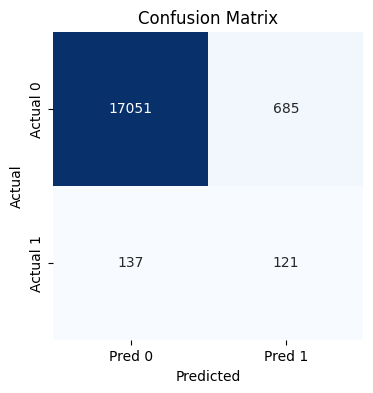

In [ ]:

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_lr1 = X_train[feature_cols].copy()
X_val_lr1 = X_val[feature_cols].copy()

# -------------------------
# CREATE MISSING INDICATORS (IMPORTANT STEP)
# -------------------------

X_train_lr1 = add_missing_indicators(X_train_lr1, num_na_cols)
X_val_lr1 = add_missing_indicators(X_val_lr1, num_na_cols)

# indicator columns
num_indicator_columns = [f"{col}_missing" for col in num_na_cols]

# -------------------------
# PIPELINES
# -------------------------

# numeric with NA → impute + scale
num_na_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# numeric without NA → scale
num_no_na_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# indicators → passthrough (NO scaling!)
indicator_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

# categorical → impute + WoE
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("woe", ce.WOEEncoder(handle_missing='value', handle_unknown='value'))
])

# -------------------------
# PREPROCESSOR
# -------------------------

preprocessor = ColumnTransformer([
    ("num_na", num_na_pipeline, num_na_cols),
    ("num_no_na", num_no_na_pipeline, num_no_na_cols),
    ("indicators", indicator_pipeline, num_indicator_columns),
    ("cat_woe", cat_pipeline, all_cat_cols),
])

# -------------------------
# MODEL
# -------------------------

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        #penalty="l2",
        #solver="lbfgs",
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])

# -------------------------
# HYPERPARAMETERS
# -------------------------

param_dist = {
    "clf__C": np.logspace(-3, 2, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_lr1 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

with mlflow.start_run(run_name="lr_v1"):
   
    random_search_lr1.fit(X_train_lr1, y_train)  # TRAIN
    results = evaluate_and_report(random_search_lr1, X_val_lr1, y_val) # EVALUATE

    # =========================
    # LOG BEST PARAMS
    # =========================

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_lr1.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_lr1.best_params_)
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("penalty", "l1")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", results["threshold"])
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix_normalized.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_lr1.best_estimator_,
            artifact_path="model",
            input_example=X_val_lr1.head(5)
    )


best_model = random_search_lr1.best_estimator_

joblib.dump({
    "model": best_model,
    "features": X_train_lr1.columns.tolist()
}, "../models/lr1_model.pkl")

In [4]:
evaluate_and_report(random_search_lr1, X_val_lr1, y_val, metric="average_precision")
#evaluate_and_report1(random_search_lr1, X_val_lr1, y_val, threshold=0.8, metric="average_precision")

Best CV average_precision: 0.15667547134582213

Best Parameters:
clf__C: 0.046415888336127795

Chosen threshold (precision >= 0.15): 0.8238

Test ROC AUC: 0.9015467598857315
Test PR AUC: 0.16604903883868574
Precision: 0.1501240694789082
Recall: 0.4689922480620155

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   17051     685
Actual 1     137     121


{'threshold': 0.8238118973185534,
 'precision': 0.1501240694789082,
 'recall': 0.4689922480620155,
 'roc_auc': 0.9015467598857315,
 'pr_auc': 0.16604903883868574,
 'confusion_matrix': array([[17051,   685],
        [  137,   121]])}

In [5]:

model = joblib.load('../models/lr1_model.pkl')["model"]
X_test, y_test = fetch_full_dataset(engine, "test_loans")
X_test_lr1 = X_test[feature_cols].copy()

X_test_lr1 = add_missing_indicators(X_test_lr1, num_na_cols)
prob = model.predict_proba(X_test_lr1)[:, 1][0]

evaluate_and_report_loaded_model(model, X_test_lr1, y_test, metric="average_precision")



Chosen threshold (precision >= 0.15): 0.7992

Test ROC AUC: 0.9063876353573679
Test PR AUC: 0.17411832311459044
Precision: 0.15010570824524314
Recall: 0.5503875968992248

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8467     402
Actual 1      58      71


{'threshold': 0.7991983483833799,
 'precision': 0.15010570824524314,
 'recall': 0.5503875968992248,
 'roc_auc': 0.9063876353573679,
 'pr_auc': 0.17411832311459044,
 'confusion_matrix': array([[8467,  402],
        [  58,   71]])}

In [6]:

# =========================
# CONFIG
# =========================

indicator_cols = [f"{col}_missing" for col in num_na_cols]

# =========================
# LOAD MODEL + SCHEMA
# =========================
bundle = joblib.load('../models/lr1_model.pkl')
model = bundle["model"]
expected_columns = bundle["features"]   # must be X_train_lr1.columns

engine = get_engine()

# =========================
# LOOP (ONE BY ONE)
# =========================
df_ids = fetch_all_ids(engine)

preds = []
probas = []
y_trues = []

for i in range(len(df_ids)):

    loan_uuid = str(df_ids.iloc[i]["uuid"])
    y_true = int(df_ids.iloc[i]["default"])
    y_trues.append(y_true)

    df_loan = fetch_loan_by_uuid(engine, loan_uuid)

    X_row = df_loan.drop(columns=["default"])[feature_cols].copy()

    X_row = X_row.replace([None, "None"], np.nan)

    X_row = add_missing_indicators(X_row, num_na_cols)

    X_row = X_row.reindex(columns=expected_columns)

    prob = model.predict_proba(X_row)[:, 1][0]
    pred = int(prob >= 0.7992)

    probas.append(prob)
    preds.append(pred)
    #display(X_row)

    #print(f"{loan_uuid} -> {prob:.6f}")


# =========================
# METRICS
# =========================
roc_auc = roc_auc_score(y_trues, probas)
pr_auc = average_precision_score(y_trues, probas)
precision = precision_score(y_trues, preds)
recall = recall_score(y_trues, preds)
cm = confusion_matrix(y_trues, preds)

print("\nTest ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))


Test ROC AUC: 0.9063876353573679
Test PR AUC: 0.17411832311459044
Precision: 0.1504237288135593
Recall: 0.5503875968992248

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8468     401
Actual 1      58      71


<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 2: Log Regression
- Numerical features -> median impute for NaNs + binning + WoE Encoding
- Categorical features -> WoE Encoding

- Potential improvements
    - monotonic binning
    - Add ratios
    - Log transforms
    - Caps - winsorization
    - try L1
    - interaction features
    - change class weight -> class_weight={0:1, 1:2}

X["debt_to_paid"] = X["recovery_debt"] / (X["sum_paid_inv_0_12m"] + 1)
X["active_to_paid"] = X["num_active_inv"] / (X["sum_paid_inv_0_12m"] + 1)

X["log_recovery_debt"] = np.log1p(X["recovery_debt"])

X["recovery_debt"] = X["recovery_debt"].clip(upper=X["recovery_debt"].quantile(0.99))

X["debt_x_active"] = X["recovery_debt"] * X["num_active_inv"]

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV average_precision: 0.1499326090195976

Best Parameters:
clf__C: 100.0

Chosen threshold (precision >= 0.15): 0.8415

Test ROC AUC: 0.898159985559087
Test PR AUC: 0.1515515396684052
Precision: 0.150066401062417
Recall: 0.437984496124031

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   17096     640
Actual 1     145     113


2026/05/06 19:40:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 19:40:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run logreg_v2 at: http://127.0.0.1:5001/#/experiments/1/runs/93dbeba2cbbb4c05963da2adce5cec90
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


['../models/lr2_model.pkl']

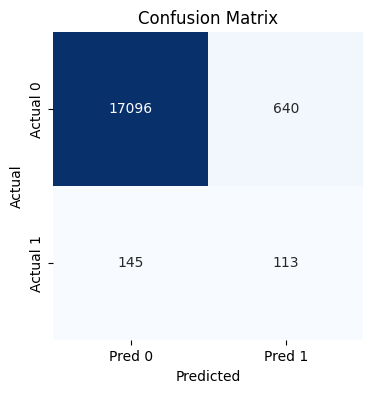

In [ ]:

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_lr2 = X_train[feature_cols].copy()
X_val_lr2 = X_val[feature_cols].copy()

# -------------------------
# CREATE MISSING INDICATORS
# -------------------------

X_train_lr2 = add_missing_indicators(X_train_lr2, num_na_cols)
X_val_lr2 = add_missing_indicators(X_val_lr2, num_na_cols)

num_indicator_columns = [f"{col}_missing" for col in num_na_cols]

# -------------------------
# PIPELINES
# -------------------------

# numeric with NA -> impute -> bin -> WoE
num_na_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("binning", QuantileBinner(n_bins=5)),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])

# numeric without NA -> bin -> WoE
num_no_na_pipeline = Pipeline([
    ("binning", QuantileBinner(n_bins=5)),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])

# indicators -> passthrough
indicator_pipeline = "passthrough"

# categorical -> impute -> WoE
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("woe", ce.WOEEncoder(handle_missing="value", handle_unknown="value"))
])

# -------------------------
# PREPROCESSOR
# -------------------------

preprocessor = ColumnTransformer([
    ("num_na", num_na_pipeline, num_na_cols),
    ("num_no_na", num_no_na_pipeline, num_no_na_cols),
    ("indicators", indicator_pipeline, num_indicator_columns),
    ("cat_woe", cat_pipeline, all_cat_cols),
])

# -------------------------
# MODEL
# -------------------------

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])

# -------------------------
# HYPERPARAMETERS
# -------------------------

param_dist = {
    "clf__C": np.logspace(-3, 2, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_lr2 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

# -------------------------
# TRAIN
# -------------------------
with mlflow.start_run(run_name="lr_v2"):

    random_search_lr2.fit(X_train_lr2, y_train.to_numpy()) #FIT
    results = evaluate_and_report(random_search_lr2, X_val_lr2, y_val) #EVALUATE


    mlflow.set_tag("encoding", "woe + quantile_binning")   

    mlflow.set_tag("model_summary", 
    "Logistic regression with WoE encoding and quantile binning (credit risk)")

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_lr2.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_lr2.best_params_)
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("penalty", "l1")
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", results["threshold"])
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix_normalized.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_lr2.best_estimator_,
            artifact_path="model",
            input_example=X_val_lr2.head(5)
    )
    
best_model = random_search_lr2.best_estimator_

joblib.dump({
    "model": best_model,
    "features": X_train_lr2.columns.tolist()
}, "../models/lr2_model.pkl")

In [8]:
evaluate_and_report(random_search_lr2, X_val_lr2, y_val)

Best CV average_precision: 0.1499326090195976

Best Parameters:
clf__C: 100.0

Chosen threshold (precision >= 0.15): 0.8415

Test ROC AUC: 0.898159985559087
Test PR AUC: 0.1515515396684052
Precision: 0.150066401062417
Recall: 0.437984496124031

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   17096     640
Actual 1     145     113


{'threshold': 0.8415470542524665,
 'precision': 0.150066401062417,
 'recall': 0.437984496124031,
 'roc_auc': 0.898159985559087,
 'pr_auc': 0.1515515396684052,
 'confusion_matrix': array([[17096,   640],
        [  145,   113]])}

In [9]:

model = joblib.load('../models/lr2_model.pkl')["model"]
X_test, y_test = fetch_full_dataset(engine, "test_loans")
X_test_lr2= X_test[feature_cols].copy()

X_test_lr2 = add_missing_indicators(X_test_lr2, num_na_cols)
prob = model.predict_proba(X_test_lr2)[:, 1][0]

evaluate_and_report_loaded_model(model, X_test_lr2, y_test, metric="average_precision")



Chosen threshold (precision >= 0.15): 0.8246

Test ROC AUC: 0.9009694074211979
Test PR AUC: 0.17278346616625995
Precision: 0.15
Recall: 0.4883720930232558

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8512     357
Actual 1      66      63


{'threshold': 0.8245501686042286,
 'precision': 0.15,
 'recall': 0.4883720930232558,
 'roc_auc': 0.9009694074211979,
 'pr_auc': 0.17278346616625995,
 'confusion_matrix': array([[8512,  357],
        [  66,   63]])}

In [10]:

# =========================
# CONFIG
# =========================

indicator_cols = [f"{col}_missing" for col in num_na_cols]

# =========================
# LOAD MODEL + SCHEMA
# =========================
bundle = joblib.load('../models/lr2_model.pkl')
model = bundle["model"]
expected_columns = bundle["features"]  # X_train_lr2.columns

engine = get_engine()

# =========================
# LOOP (ONE BY ONE)
# =========================
df_ids = fetch_all_ids(engine)

preds = []
probas = []
y_trues = []

for i in range(len(df_ids)):

    loan_uuid = str(df_ids.iloc[i]["uuid"])
    y_true = int(df_ids.iloc[i]["default"])
    y_trues.append(y_true)

    df_loan = fetch_loan_by_uuid(engine, loan_uuid)


    X_row = df_loan.drop(columns=["default"])[feature_cols].copy()

    X_row = X_row.replace([None, "None"], np.nan)

    X_row = add_missing_indicators(X_row, num_na_cols)

    X_row = X_row.reindex(columns=expected_columns)

    assert list(X_row.columns) == list(expected_columns), "Column mismatch!"
    

    prob = model.predict_proba(X_row)[:, 1][0]
    pred = int(prob >= 0.8246)

    probas.append(prob)
    preds.append(pred)

    #print(f"{loan_uuid} -> {prob:.6f}")

# =========================
# METRICS
# =========================
roc_auc = roc_auc_score(y_trues, probas)
pr_auc = average_precision_score(y_trues, probas)
precision = precision_score(y_trues, preds)
recall = recall_score(y_trues, preds)
cm = confusion_matrix(y_trues, preds)

print("\n=========================")
print("LR2 ONE-BY-ONE RESULTS")
print("=========================")

print("Test ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))


LR2 ONE-BY-ONE RESULTS
Test ROC AUC: 0.9009694074211979
Test PR AUC: 0.17278346616625995
Precision: 0.15035799522673032
Recall: 0.4883720930232558

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8513     356
Actual 1      66      63


<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 3: XGBoost
- No feature manipulation

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   5.7s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   5.9s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   5.7s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   6.0s
[CV] END colsample_bytree=0.8, gamma=1.0, learning_rate=0.05, max_depth=5, min_child_weight=10, n_estimators=200, reg_alpha=2.25, reg_lambda=0.75, subsample=1.0; total time=   5.9s
[CV] END colsample_bytree=0.8, gam

2026/05/06 19:48:26 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: MlflowException("Failed to enforce schema of data '      account_status account_worst_status_0_3m account_worst_status_12_24m  \\\n1837             NaN                       NaN                         NaN   \n38392        1.00000                   1.00000                     1.00000   \n20104            NaN                       NaN                         NaN   \n29781            NaN                       NaN                         NaN   \n55902        1.00000                   1.00000                     1.00000   \n\n      account_worst_status_3_6m account_worst_status_6_12m  \\\n1837                        NaN                        NaN   \n38392                   1.00000                    1.00000   \n20104                       NaN                        NaN   \n29781                       NaN                        NaN   \n55902                   1.00000    

🏃 View run xgb_v1 at: http://127.0.0.1:5001/#/experiments/1/runs/ccf376c0ee5a4d38adcc01b52f84298b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


['../models/xgb1_model.pkl']

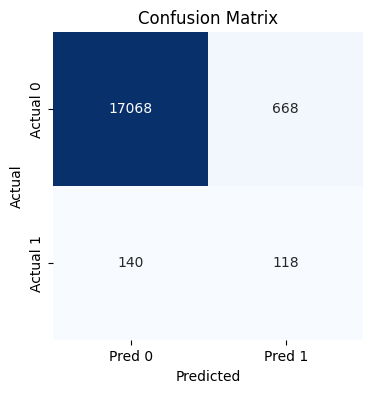

In [ ]:

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_xgb1 = X_train[feature_cols].copy()
X_val_xgb1 = X_val[feature_cols].copy()

# =========================
# CAST CATEGORICAL COLUMNS
# =========================

for col in  :
    X_train_xgb1[col] = X_train_xgb1[col].astype("category")
    X_val_xgb1[col] = X_val_xgb1[col].astype("category")
    X_val_xgb1[col] = X_val_xgb1[col].cat.set_categories(
        X_train_xgb1[col].cat.categories
    )

# =========================
# CLASS IMBALANCE
# =========================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# =========================
# MODEL
# =========================

model = XGBClassifier(
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    enable_categorical=True,
    tree_method="hist",
)

# =========================
# HYPERPARAMETERS
# =========================

param_dist = {
    "n_estimators": [200, 300, 500, 1000],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": np.linspace(0, 2, 5),
    "min_child_weight": [1, 3, 5, 10],
    "reg_lambda": np.linspace(0, 3, 5),
    "reg_alpha": np.linspace(0, 3, 5),
}

# =========================
# CROSS-VALIDATION
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb1 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score="raise",
)


with mlflow.start_run(run_name="xgb_v1"):

    random_search_xgb1.fit(X_train_xgb1, y_train)

    results =  evaluate_and_report(
        random_search_xgb1,
        X_val_xgb1,
        y_val,
        metric="average_precision",
    )


    mlflow.set_tag("encoding", "no encoding done")   
    mlflow.set_tag("model_summary", "XgBoost")

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_xgb1.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_xgb1.best_params_)
    mlflow.log_param("model_type", "XgBoost")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", results["threshold"])
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_xgb1.best_estimator_,
            name="model",
            input_example=X_val_xgb1.head(5)
    )
    
    
best_model = random_search_xgb1.best_estimator_


joblib.dump({
    "model": best_model,
    "features": X_train_xgb1.columns.tolist()
}, "../models/xgb1_model.pkl")

In [12]:
evaluate_and_report(random_search_xgb1, X_val_xgb1, y_val, metric="average_precision")

Best CV average_precision: 0.18378868449033453

Best Parameters:
subsample: 0.9
reg_lambda: 3.0
reg_alpha: 2.25
n_estimators: 1000
min_child_weight: 10
max_depth: 8
learning_rate: 0.02
gamma: 1.5
colsample_bytree: 0.9

Chosen threshold (precision >= 0.15): 0.3481

Test ROC AUC: 0.8897085112223027
Test PR AUC: 0.2559146825020539
Precision: 0.15012722646310434
Recall: 0.4573643410852713

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   17068     668
Actual 1     140     118


{'threshold': 0.3481467,
 'precision': 0.15012722646310434,
 'recall': 0.4573643410852713,
 'roc_auc': 0.8897085112223027,
 'pr_auc': 0.2559146825020539,
 'confusion_matrix': array([[17068,   668],
        [  140,   118]])}

In [26]:

# =========================
# LOAD MODEL
# =========================
bundle = joblib.load('../models/xgb1_model.pkl')
model = bundle["model"]

X_train_full, _ = fetch_train_dataset(engine)
X_train_full = X_train_full[feature_cols].copy()

# normalize missing (important for consistency)
X_train_full = X_train_full.replace([None, "None"], np.nan)

# numeric
for col in all_num_cols:
    if col in X_train_full.columns:
        X_train_full[col] = pd.to_numeric(X_train_full[col], errors="coerce")

# categorical
for col in all_cat_cols:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].astype("category")

# =========================
# CATEGORY MAP (🔥 KEY FIX)
# =========================
categories_map = {
    col: X_train_full[col].cat.categories
    for col in all_cat_cols
}

# =========================
# LOAD TEST DATA
# =========================
X_test, y_test = fetch_full_dataset(engine, "test_loans")

X_test_xgb1 = X_test[feature_cols].copy()

# normalize missing
X_test_xgb1 = X_test_xgb1.replace([None, "None"], np.nan)

# numeric
for col in all_num_cols:
    if col in X_test_xgb1.columns:
        X_test_xgb1[col] = pd.to_numeric(X_test_xgb1[col], errors="coerce")

# categorical WITH alignment 🔥
for col in all_cat_cols:
    if col in X_test_xgb1.columns:
        X_test_xgb1[col] = pd.Categorical(
            X_test_xgb1[col],
            categories=categories_map[col]
        )

# =========================
# EVALUATE
# =========================
evaluate_and_report_loaded_model(
    model,
    X_test_xgb1,
    y_test,
    metric="average_precision"
)


Chosen threshold (precision >= 0.15): 0.7204

Test ROC AUC: 0.8773093459406119
Test PR AUC: 0.1620912465697626
Precision: 0.15034965034965034
Recall: 0.3333333333333333

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8626     243
Actual 1      86      43


{'threshold': 0.7204117,
 'precision': 0.15034965034965034,
 'recall': 0.3333333333333333,
 'roc_auc': 0.8773093459406119,
 'pr_auc': 0.1620912465697626,
 'confusion_matrix': array([[8626,  243],
        [  86,   43]])}

In [14]:

# =========================
# LOAD MODEL
# =========================
bundle = joblib.load('../models/xgb1_model.pkl')
model = bundle["model"]

engine = get_engine()

X_train_full, y_train_full = fetch_train_dataset(engine)

# keep only features
X_train_full = X_train_full[feature_cols].copy()

# ===== NUMERIC =====
for col in all_num_cols:
    if col in X_train_full.columns:
        X_train_full[col] = pd.to_numeric(X_train_full[col], errors="coerce")

# ===== CATEGORICAL =====
for col in all_cat_cols:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].astype("category")

# =========================
# CATEGORY MAP (FROM TRAIN ONLY 🔥)
# =========================
categories_map = {
    col: X_train_full[col].cat.categories
    for col in all_cat_cols
}

# =========================
# EXPECTED FEATURES (TRAIN SCHEMA)
# =========================
expected_features = X_train_full.columns.tolist()



df_ids = fetch_all_ids(engine)

# =========================
# LOOP (ONE BY ONE)
# =========================
preds = []
probas = []
y_trues = []

for i in range(len(df_ids)):

    loan_uuid = str(df_ids.iloc[i]["uuid"])
    y_true = int(df_ids.iloc[i]["default"])
    y_trues.append(y_true)

    df_loan = fetch_loan_by_uuid(engine, loan_uuid)

    # ===== RAW =====
    X_row = df_loan.drop(columns=["default"]).copy()

    # ===== ALIGN TO TRAIN SCHEMA 🔥
    X_row = X_row.reindex(columns=expected_features)

    # ===== NUMERIC =====
    for col in all_num_cols:
        if col in X_row.columns:
            X_row[col] = pd.to_numeric(X_row[col], errors="coerce")

    # ===== CATEGORICAL =====
    for col in all_cat_cols:
        if col in X_row.columns:
            X_row[col] = pd.Categorical(
                X_row[col],
                categories=categories_map[col]
            )

    # ===== PREDICT =====
    prob = model.predict_proba(X_row)[:, 1][0]
    pred = int(prob >= 0.3667)

    probas.append(prob)
    preds.append(pred)

    #print(f"{loan_uuid} -> {prob:.6f}")

# =========================
# METRICS
# =========================
roc_auc = roc_auc_score(y_trues, probas)
pr_auc = average_precision_score(y_trues, probas)
precision = precision_score(y_trues, preds)
recall = recall_score(y_trues, preds)
cm = confusion_matrix(y_trues, preds)

print("\nTest ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))


Test ROC AUC: 0.8880955440122856
Test PR AUC: 0.17955096214049315
Precision: 0.15015015015015015
Recall: 0.3875968992248062

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8586     283
Actual 1      79      50


<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 4: XGBoost
- WoE Encoding for categorical and numerical values with NaNs 

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  38.3s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  38.1s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  38.0s
[CV] END clf__colsample_bytree=0.8, clf__gamma=1.0, clf__learning_rate=0.05, clf__max_depth=5, clf__min_child_weight=10, clf__n_estimators=200, clf__reg_alpha=2.25, clf__reg_lambda=0.75, clf__subsample=1.0; total time=  38.4s
[CV] END clf__colsample_bytree=0.8,

2026/05/06 20:00:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run xgb_v2 at: http://127.0.0.1:5001/#/experiments/1/runs/9c81b6f68c5b4e6fb6cfd019d8892fac
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


['../models/xgb2_model.pkl']

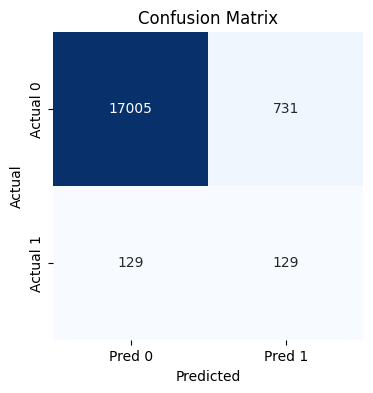

In [15]:

# =========================
# KEEP ONLY MODEL FEATURES
# =========================

X_train_xgb2 = X_train[feature_cols].copy()
X_val_xgb2 = X_val[feature_cols].copy()


# numeric with NA → bin + WoE
num_na_pipeline = Pipeline([
    ("binning", QuantileBinner(n_bins=10)),
    ("woe", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

# numeric without NA → passthrough
num_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

# categorical → WoE (NA handled internally)
cat_pipeline = Pipeline([
    ("encoder", ce.WOEEncoder(handle_unknown='value', handle_missing='value'))
])

preprocessor = ColumnTransformer([
    ("num_na_woe", num_na_pipeline, num_na_cols),
    ("num", num_pipeline, num_no_na_cols),
    ("cat_woe", cat_pipeline, all_cat_cols),
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", XGBClassifier(
        #eval_metric="auc",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False
    ))
])

param_dist = {
    "clf__n_estimators": [200,300,500,1000],
    "clf__max_depth": [3, 5, 8],
    "clf__learning_rate": [0.01, 0.02, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__gamma": np.linspace(0, 2, 5),
    "clf__min_child_weight": [1, 3, 5, 10],
    "clf__reg_lambda": np.linspace(0, 3, 5),
    "clf__reg_alpha": np.linspace(0, 3, 5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb2 = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    #scoring="roc_auc",
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

with mlflow.start_run(run_name="xgb_v2"):

    # MODEL TRAINING
    random_search_xgb2.fit(X_train_xgb2, y_train)

    results = evaluate_and_report(
        random_search_xgb2, 
        X_val_xgb2, y_val,
        metric="average_precision"
    )


    mlflow.set_tag("encoding", "for categorical and numerical features with NaNs: Binning + WoE")   
    mlflow.set_tag("model_summary", "XgBoost")

    mlflow.log_input(
        mlflow.data.from_pandas(X_val_xgb2.head(1000), name="val_sample"),
        context="validation"
        )

    mlflow.log_params(random_search_xgb2.best_params_)
    mlflow.log_param("model_type", "XgBoost")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("scoring", "average_precision")
    mlflow.log_param("threshold", results["threshold"])
    
    # =========================
    # LOG METRICS
    # =========================
    results_without_cm = {k: float(v) for k, v in results.items() if k != "confusion_matrix"}
    mlflow.log_metrics(results_without_cm)

    cm = results["confusion_matrix"]
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix.png")
    
    # =========================
    # LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
            random_search_xgb2.best_estimator_,
            name="model",
            input_example=X_val_xgb2.head(5)
    )

best_model = random_search_xgb2.best_estimator_
joblib.dump({
    "model": best_model,
    "features": X_train_xgb2.columns.tolist()
}, "../models/xgb2_model.pkl")

In [16]:
evaluate_and_report(random_search_xgb2, X_val_xgb2, y_val, metric="average_precision")

Best CV average_precision: 0.20337177826826963

Best Parameters:
clf__subsample: 1.0
clf__reg_lambda: 0.75
clf__reg_alpha: 2.25
clf__n_estimators: 200
clf__min_child_weight: 10
clf__max_depth: 5
clf__learning_rate: 0.05
clf__gamma: 1.0
clf__colsample_bytree: 0.8

Chosen threshold (precision >= 0.15): 0.7437

Test ROC AUC: 0.8922779578521153
Test PR AUC: 0.22505213347673642
Precision: 0.15
Recall: 0.5

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   17005     731
Actual 1     129     129


{'threshold': 0.74369234,
 'precision': 0.15,
 'recall': 0.5,
 'roc_auc': 0.8922779578521153,
 'pr_auc': 0.22505213347673642,
 'confusion_matrix': array([[17005,   731],
        [  129,   129]])}

In [17]:

bundle = joblib.load('../models/xgb2_model.pkl')
model = bundle["model"]
expected_features = bundle["features"]


X_test, y_test = fetch_full_dataset(engine, "test_loans")

X_test_xgb2 = X_test[feature_cols].copy()

X_test_xgb2 = X_test_xgb2.replace([None, "None"], np.nan)

X_test_xgb2 = X_test_xgb2.reindex(columns=expected_features)


assert list(X_test_xgb2.columns) == list(expected_features), "Column mismatch!"

# =========================
# EVALUATE
# =========================
evaluate_and_report_loaded_model(
    model,
    X_test_xgb2,
    y_test,
    metric="average_precision"
)


Chosen threshold (precision >= 0.15): 0.7250

Test ROC AUC: 0.8972848550958351
Test PR AUC: 0.19645742627651852
Precision: 0.15
Recall: 0.5813953488372093

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8444     425
Actual 1      54      75


{'threshold': 0.72504497,
 'precision': 0.15,
 'recall': 0.5813953488372093,
 'roc_auc': 0.8972848550958351,
 'pr_auc': 0.19645742627651852,
 'confusion_matrix': array([[8444,  425],
        [  54,   75]])}

In [18]:

# =========================
# CONFIG
# =========================
THRESHOLD = 0.7250

# =========================
# LOAD MODEL
# =========================
bundle = joblib.load('../models/xgb2_model.pkl')
model = bundle["model"]

engine = get_engine()

X_train_full, y_train_full = fetch_train_dataset(engine)

# keep only features
X_train_full = X_train_full[feature_cols].copy()

# ===== NUMERIC =====
for col in all_num_cols:
    if col in X_train_full.columns:
        X_train_full[col] = pd.to_numeric(X_train_full[col], errors="coerce")

# ===== CATEGORICAL =====
for col in all_cat_cols:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].astype("category")

# =========================
# CATEGORY MAP (FROM TRAIN ONLY 🔥)
# =========================
categories_map = {
    col: X_train_full[col].cat.categories
    for col in all_cat_cols
}

# =========================
# EXPECTED FEATURES (TRAIN SCHEMA)
# =========================
expected_features = X_train_full.columns.tolist()

df_ids = fetch_all_ids(engine)

# =========================
# LOOP (ONE BY ONE)
# =========================
preds = []
probas = []
y_trues = []

for i in range(len(df_ids)):

    loan_uuid = str(df_ids.iloc[i]["uuid"])
    y_true = int(df_ids.iloc[i]["default"])

    df_loan = fetch_loan_by_uuid(engine, loan_uuid)

    # ===== RAW =====
    X_row = df_loan.drop(columns=["default"]).copy()

    # ===== ALIGN TO TRAIN SCHEMA 🔥
    X_row = X_row.reindex(columns=expected_features)

    # ===== NUMERIC FIRST (important!)
    for col in all_num_cols:
        if col in X_row.columns:
            X_row[col] = pd.to_numeric(X_row[col], errors="coerce")

    # ===== CATEGORICAL WITH FIXED LEVELS
    for col in all_cat_cols:
        if col in X_row.columns:
            X_row[col] = pd.Categorical(
                X_row[col],
                categories=categories_map[col]
            )

    # ===== SAFETY CHECK
    # if list(X_row.columns) != expected_features:
    #     raise ValueError("Feature mismatch!")

    # ===== PREDICT =====
    prob = model.predict_proba(X_row)[:, 1][0]
    pred = int(prob >= THRESHOLD)

    probas.append(prob)
    preds.append(pred)
    y_trues.append(y_true)

    # DEBUG (optional)
    # print(f"{loan_uuid} -> {prob:.6f}")

# =========================
# METRICS
# =========================
roc_auc = roc_auc_score(y_trues, probas)
pr_auc = average_precision_score(y_trues, probas)
precision = precision_score(y_trues, preds, zero_division=0)
recall = recall_score(y_trues, preds, zero_division=0)
cm = confusion_matrix(y_trues, preds)

print("\nTest ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))


Test ROC AUC: 0.8972848550958351
Test PR AUC: 0.19645742627651852
Precision: 0.15
Recall: 0.5813953488372093

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8444     425
Actual 1      54      75


<div style="background-color:#fff8dc; padding:15px;  color:black;">

## Model 5: Dense Neural Network
- Median inpute for NaNs of numerical features
- Numerical features are standardized
- Categorical features are encoded

</div>

Epoch 1 | Train: 1.1350 | Val: 1.0496 | AUC: 0.8577 | PR: 0.1048
Epoch 2 | Train: 1.0117 | Val: 0.9996 | AUC: 0.8692 | PR: 0.1189
Epoch 3 | Train: 0.9610 | Val: 0.9700 | AUC: 0.8745 | PR: 0.1252
Epoch 4 | Train: 0.9250 | Val: 0.9442 | AUC: 0.8777 | PR: 0.1272
Epoch 5 | Train: 0.8885 | Val: 0.9105 | AUC: 0.8806 | PR: 0.1352
Epoch 6 | Train: 0.8588 | Val: 0.8976 | AUC: 0.8823 | PR: 0.1371
Epoch 7 | Train: 0.8271 | Val: 0.8905 | AUC: 0.8809 | PR: 0.1420
Epoch 8 | Train: 0.8040 | Val: 0.8791 | AUC: 0.8826 | PR: 0.1357
Epoch 9 | Train: 0.7732 | Val: 0.8709 | AUC: 0.8838 | PR: 0.1366
Epoch 10 | Train: 0.7609 | Val: 0.8731 | AUC: 0.8821 | PR: 0.1484
Epoch 11 | Train: 0.7371 | Val: 0.8607 | AUC: 0.8861 | PR: 0.1390
Epoch 12 | Train: 0.7306 | Val: 0.8669 | AUC: 0.8836 | PR: 0.1356
Epoch 13 | Train: 0.7251 | Val: 0.8749 | AUC: 0.8839 | PR: 0.1352
Epoch 14 | Train: 0.7363 | Val: 0.8695 | AUC: 0.8850 | PR: 0.1438
Epoch 15 | Train: 0.6899 | Val: 0.8662 | AUC: 0.8863 | PR: 0.1416
Early stopping


2026/05/06 20:05:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/06 20:05:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run dnn_v1 at: http://127.0.0.1:5001/#/experiments/1/runs/8a885b4a9db544539c6e406cc199fd97
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


['../models/dnn1_model.pkl']

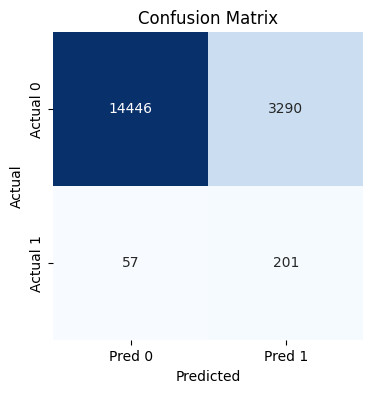

In [19]:

# =========================
# 0. SEED
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# 1. COPY DATA
# =========================

X_train_nn1 = X_train.copy()
X_val_nn1 = X_val.copy()

# =========================
# 2. DEFINE COLUMNS
# =========================

cat_columns = cat_na_cols + cat_no_na_cols
num_columns = num_na_cols + num_no_na_cols

# =========================
# 3. ENCODE CATEGORICALS
# =========================

cat_encoders = {}

for col in cat_columns:
    X_train_nn1[col] = X_train_nn1[col].astype(str).fillna("MISSING")
    X_val_nn1[col] = X_val_nn1[col].astype(str).fillna("MISSING")
    
    unique_vals = sorted(X_train_nn1[col].unique().tolist())
    
    if "MISSING" not in unique_vals:
        unique_vals.append("MISSING")
    
    encoder = {val: i for i, val in enumerate(unique_vals)}
    
    X_train_nn1[col] = X_train_nn1[col].map(encoder).astype(int)
    X_val_nn1[col] = X_val_nn1[col].map(
        lambda x: encoder.get(x, encoder["MISSING"])
    ).astype(int)
    
    cat_encoders[col] = encoder

# =========================
# 4. NUMERICAL PREPROCESSING
# =========================

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_nn1[num_columns] = imputer.fit_transform(X_train_nn1[num_columns])
X_val_nn1[num_columns] = imputer.transform(X_val_nn1[num_columns])

X_train_nn1[num_columns] = scaler.fit_transform(X_train_nn1[num_columns])
X_val_nn1[num_columns] = scaler.transform(X_val_nn1[num_columns])

# =========================
# 5. DATASET
# =========================

class TabularDataset(Dataset):
    def __init__(self, X, y, cat_cols, num_cols):
        self.X_cat = torch.tensor(X[cat_cols].values, dtype=torch.long)
        self.X_num = torch.tensor(X[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

# =========================
# 6. DATALOADERS
# =========================

train_dataset = TabularDataset(X_train_nn1, y_train, cat_columns, num_columns)
val_dataset = TabularDataset(X_val_nn1, y_val, cat_columns, num_columns)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# =========================
# 7. MODEL
# =========================

class TabularNN(nn.Module):
    def __init__(self, cat_dims, num_dim):
        super().__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, min(16, int(cat_dim**0.5)))
            for cat_dim in cat_dims
        ])
        
        emb_dim = sum([emb.embedding_dim for emb in self.embeddings])
        
        self.model = nn.Sequential(
            nn.Linear(emb_dim + num_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x_cat, x_num):
        emb = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.embeddings)]
        x = torch.cat(emb + [x_num], dim=1)
        return self.model(x).squeeze(1)

# =========================
# 8. INIT MODEL
# =========================

cat_dims = [len(cat_encoders[col]) for col in cat_columns]
num_dim = len(num_columns)

model = TabularNN(cat_dims, num_dim)

# =========================
# 9. TRAINING SETUP
# =========================

optimizer = optim.Adam(model.parameters(), lr=0.0001)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# =========================
# 10. TRAINING LOOP + EARLY STOPPING
# =========================


EPOCHS = 50
patience = 5

best_pr = 0
counter = 0
best_state = None
best_epoch = 0

# safe reset (notebook friendly)
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="dnn_v1"):

    # ===== TAGS =====
    mlflow.set_tag("model_type", "dnn")
    mlflow.set_tag("encoding", "median_imputation + standardization")

    # ===== PARAMS =====
    mlflow.log_params({
        "epochs": EPOCHS,
        "batch_size": 256,
        "learning_rate": 1e-4,
        "patience": patience
    })

    for epoch in range(EPOCHS):

        # ===== TRAIN =====
        model.train()
        total_loss = 0

        for x_cat, x_num, y_batch in train_loader:
            optimizer.zero_grad()

            logits = model(x_cat, x_num)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for x_cat, x_num, y_batch in val_loader:
                logits = model(x_cat, x_num)

                val_loss += criterion(logits, y_batch).item()

                probs = torch.sigmoid(logits)
                all_preds.append(probs.cpu())
                all_targets.append(y_batch.cpu())

        all_preds = torch.cat(all_preds).numpy()
        all_targets = torch.cat(all_targets).numpy()

        val_loss /= len(val_loader)
        val_auc = roc_auc_score(all_targets, all_preds)
        val_pr = average_precision_score(all_targets, all_preds)

        # ===== LOG TRAINING METRICS =====
        mlflow.log_metrics({
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_auc": val_auc,
            "val_pr": val_pr
        }, step=epoch)

        print(
            f"Epoch {epoch+1} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f} | "
            f"AUC: {val_auc:.4f} | "
            f"PR: {val_pr:.4f}"
        )

        # ===== EARLY STOPPING =====
        improved = val_pr > best_pr
        best_pr = val_pr if improved else best_pr
        counter = 0 if improved else counter + 1

        if improved:
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if counter >= patience:
            print("Early stopping")
            break

    # ===== LOAD BEST MODEL =====
    model.load_state_dict(best_state)
    model.eval()

    # ===== FINAL EVALUATION =====
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x_cat, x_num, y_batch in val_loader:
            logits = model(x_cat, x_num)
            probs = torch.sigmoid(logits)

            all_preds.append(probs.cpu())
            all_targets.append(y_batch.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    # ===== FINAL METRICS =====
    roc_auc = roc_auc_score(all_targets, all_preds)
    pr_auc = average_precision_score(all_targets, all_preds)

    threshold = 0.5
    pred_labels = (all_preds > threshold).astype(int)

    precision = precision_score(all_targets, pred_labels)
    recall = recall_score(all_targets, pred_labels)

    cm = confusion_matrix(all_targets, pred_labels)

    # ===== LOG FINAL METRICS =====
    mlflow.log_metrics({
        "best_val_pr": best_pr,
        "best_epoch": best_epoch,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall
    })

    # ===== LOG CONFUSION MATRIX =====
    fig = plot_confusion_matrix(cm)
    mlflow.log_figure(fig, "confusion_matrix.png")

    # ===== LOG MODEL =====
    mlflow.pytorch.log_model(model, name="model")



joblib.dump({
    "model_state_dict": model.state_dict(),
    "cat_encoders": cat_encoders,
    "imputer": imputer,
    "scaler": scaler,
    "cat_columns": cat_columns,
    "num_columns": num_columns,
    "feature_cols": feature_cols,
    "cat_dims": cat_dims,
    "num_dim": num_dim
}, "../models/dnn1_model.pkl")

In [20]:
evaluate_nn(model, val_loader)


Chosen threshold (precision >= 0.15): 0.8511

Evaluation Results
------------------
ROC AUC: 0.882090427038424
PR AUC: 0.1483969463417645
Precision: 0.15009041591320071
Recall: 0.32170542635658916

Confusion Matrix:
          Pred 0  Pred 1
Actual 0   17266     470
Actual 1     175      83


{'threshold': 0.85107017,
 'roc_auc': 0.882090427038424,
 'pr_auc': 0.1483969463417645,
 'precision': 0.15009041591320071,
 'recall': 0.32170542635658916,
 'confusion_matrix': array([[17266,   470],
        [  175,    83]])}

In [21]:
def preprocess_nn_input(df_raw, bundle):
    import numpy as np
    import pandas as pd

    df = df_raw.copy()

    cat_encoders = bundle["cat_encoders"]
    imputer = bundle["imputer"]
    scaler = bundle["scaler"]
    cat_columns = bundle["cat_columns"]
    num_columns = bundle["num_columns"]
    expected_features = bundle["feature_cols"]

    # =========================
    # ALIGN COLUMNS
    # =========================
    df = df.reindex(columns=expected_features)

    # =========================
    # NUMERICAL
    # =========================
    for col in num_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df[num_columns] = imputer.transform(df[num_columns])
    df[num_columns] = scaler.transform(df[num_columns])
    df[num_columns] = df[num_columns].astype(np.float32)

    # =========================
    # CATEGORICAL (FINAL FIX 🔥)
    # =========================
    for col in cat_columns:
        enc = cat_encoders[col]

        # normalize first
        df[col] = df[col].astype(str).str.strip().str.upper()

        # unify missing representations
        df[col] = df[col].replace(
            ["NONE", "NAN", "NULL", ""],
            np.nan
        )

        # fill missing consistently
        df[col] = df[col].fillna("MISSING")

        # encode
        df[col] = df[col].map(
            lambda x: enc.get(x, enc["MISSING"])
        ).astype(np.int64)

    return df

In [22]:

# =========================
# LOAD MODEL
# =========================
bundle = joblib.load('../models/dnn1_model.pkl')

cat_columns = bundle["cat_columns"]
num_columns = bundle["num_columns"]
cat_dims = bundle["cat_dims"]
num_dim = bundle["num_dim"]

model = TabularNN(cat_dims, num_dim)
model.load_state_dict(bundle["model_state_dict"])
model.eval()

# =========================
# LOAD DATA
# =========================
X_test, y_test = fetch_full_dataset(engine, "test_loans")

# =========================
# PREPROCESS
# =========================
X_test_nn = preprocess_nn_input(X_test, bundle)

# =========================
# TO TENSOR
# =========================
X_cat = torch.tensor(X_test_nn[cat_columns].values, dtype=torch.long)
X_num = torch.tensor(X_test_nn[num_columns].values, dtype=torch.float32)

# =========================
# PREDICT
# =========================
with torch.no_grad():
    logits = model(X_cat, X_num)
    probs = torch.sigmoid(logits).cpu().numpy().flatten()

# =========================
# EVALUATE
# =========================
threshold = 0.73
preds = (probs >= threshold).astype(int)

roc_auc = roc_auc_score(y_test, probs)
pr_auc = average_precision_score(y_test, probs)
precision = precision_score(y_test, preds, zero_division=0)
recall = recall_score(y_test, preds, zero_division=0)
cm = confusion_matrix(y_test, preds)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))


Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8360     509
Actual 1      73      56


In [23]:

# =========================
# LOAD MODEL
# =========================
bundle = joblib.load('../models/dnn1_model.pkl')

cat_columns = bundle["cat_columns"]
num_columns = bundle["num_columns"]
cat_dims = bundle["cat_dims"]
num_dim = bundle["num_dim"]

model = TabularNN(cat_dims, num_dim)
model.load_state_dict(bundle["model_state_dict"])
model.eval()

engine = get_engine()

df_ids = fetch_all_ids(engine)

# =========================
# LOOP
# =========================
probas = []
preds = []
y_trues = []

threshold = 0.73

for i in range(len(df_ids)):

    loan_uuid = str(df_ids.iloc[i]["uuid"])
    y_true = int(df_ids.iloc[i]["default"])

    df_loan = fetch_loan_by_uuid(engine, loan_uuid)

    X_row_raw = df_loan.drop(columns=["default"])

    # =========================
    # PREPROCESS (SAME FUNCTION)
    # =========================
    X_row = preprocess_nn_input(X_row_raw, bundle)

    # =========================
    # TO TENSOR
    # =========================
    X_cat = torch.tensor(X_row[cat_columns].values, dtype=torch.long)
    X_num = torch.tensor(X_row[num_columns].values, dtype=torch.float32)

    with torch.no_grad():
        logits = model(X_cat, X_num)
        prob = torch.sigmoid(logits).item()

    pred = int(prob >= threshold)

    probas.append(prob)
    preds.append(pred)
    y_trues.append(y_true)

# =========================
# METRICS
# =========================
roc_auc = roc_auc_score(y_trues, probas)
pr_auc = average_precision_score(y_trues, probas)
precision = precision_score(y_trues, preds, zero_division=0)
recall = recall_score(y_trues, preds, zero_division=0)
cm = confusion_matrix(y_trues, preds)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))


Confusion Matrix:
          Pred 0  Pred 1
Actual 0    8334     535
Actual 1      79      50


#### SHAP - Feature Importance

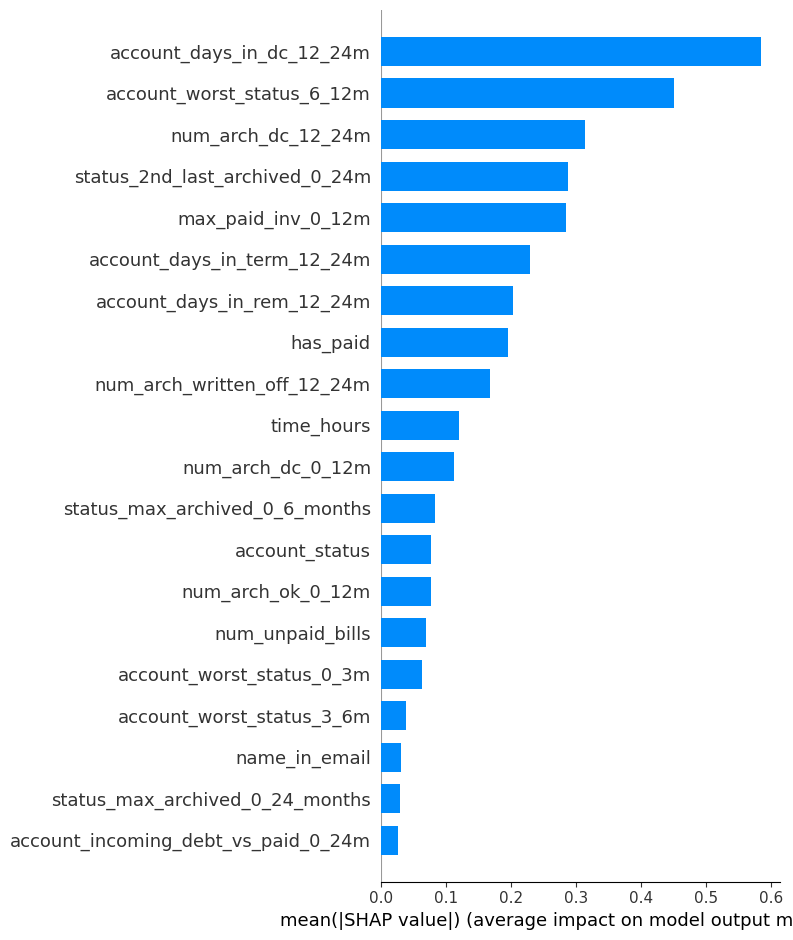

In [24]:

mod = random_search_xgb2.best_estimator_

preprocessor = mod.named_steps["preprocessing"]
xgb_model = mod.named_steps["clf"]

temp = X_test_xgb2.iloc[[0]].copy()
temp = temp[feature_cols]  # ensure order


X_transformed = preprocessor.transform(temp)

assert X_transformed.shape[1] == len(feature_cols)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_cols,
    plot_type="bar"
)